# What the sensors can see

The earlier notebooks found something that deserves its own explanation. The
surrogate (notebook 03) and the classical inversion (notebook 02) both recover
the plasma current `Ip` and position (`R0`, `Z0`) very well from CUTE's
sensors, and both do badly on the minor radius `a`. This notebook answers two
questions properly:

1. **Where are CUTE's sensors, and what does each one measure?**
2. **Why can those sensors pin down `Ip`, `R0` and `Z0`, but not `a`?**

The answer to the second is not "the network is not good enough". It is a
property of where the sensors are and of the physics, and it can be measured
before training anything. That is worth knowing how to do, because it tells you
what *any* method could achieve with a given set of sensors.

**Scope.** Sensor positions are CUTE's real diagnostic layout. The signals are
computed from the reduced forward model in `src/ml/dataset.py` (a plasma made of
circular current filaments), not measured and not from a Grad-Shafranov solve.
No Open Fusion Toolkit needed.

## Setup

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.path import Path

REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.forward.filament import loop_flux
from src.forward.sensors import generate_cute_sensors
from src.ml.dataset import PARAM_NAMES, PARAM_RANGES, SensorLayout, forward_signals, generate_dataset

with open(os.path.join(REPO_ROOT, "config", "cute_diagnostics.json")) as f:
    table = json.load(f)          # the diagnostics table, exactly as transcribed
with open(os.path.join(REPO_ROOT, "config", "CUTE_geom.json")) as f:
    geom = json.load(f)           # vessel and coils (the public OFT CUTE example)

sensors = generate_cute_sensors()  # what the models actually use
layout = SensorLayout.from_config(sensors)
print(f"table: {len(table['flux_loops'])} flux loops, {len(table['magnetic_probes'])} probe entries")
print(f"used:  {sensors.n_flux_loops} flux loops, {sensors.n_mirnov_probes} probe channels, "
      f"{sensors.n_total} in total")

table: 39 flux loops, 32 probe entries
used:  39 flux loops, 25 probe channels, 64 in total


## 1. The machine in one slice

A tokamak is (nearly) the same all the way around, so everything here is drawn
in one cross-section, the **poloidal plane**. `R` is the distance out from the
machine's vertical axis and `Z` is height. The doughnut has been cut through
and you are looking at the cut face.

The picture below shows:

- the **vacuum vessel** (grey), the steel chamber that holds the plasma. Its
  inner and outer surfaces are 5 mm apart;
- the **coils** (orange rectangles): the central solenoid stack at small `R`
  and the poloidal field coils around the outside, which push and shape the
  plasma;
- the **flux loops**: `FS` loops (blue circles) run around the outside of the
  vessel, and `FC` loops (blue squares) sit on the centre column, the narrow
  post in the doughnut's hole;
- the **magnetic probes** (red), each with an arrow showing the direction its
  coil points. A dashed circle marks where a typical plasma sits.

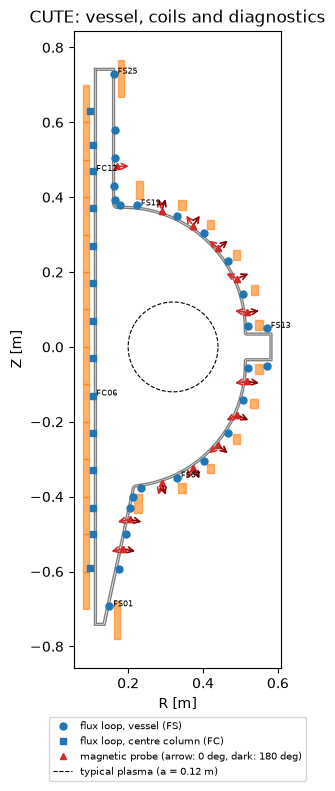

In [2]:
fig, ax = plt.subplots(figsize=(6, 8))

for name in ("inner_contour", "outer_contour"):
    c = np.array(geom["vv"][name])
    ax.plot(c[:, 0], c[:, 1], color="0.5", lw=1)

for name, coil in geom["coils"].items():
    ax.add_patch(Rectangle((coil["rc"] - coil["w"] / 2, coil["zc"] - coil["h"] / 2),
                           coil["w"], coil["h"], color="tab:orange", alpha=0.6))

fs = [s for s in table["flux_loops"] if s["name"].startswith("FS")]
fc = [s for s in table["flux_loops"] if s["name"].startswith("FC")]
ax.plot([s["R"] for s in fs], [s["Z"] for s in fs], "o", color="tab:blue", ms=5, label="flux loop, vessel (FS)")
ax.plot([s["R"] for s in fc], [s["Z"] for s in fc], "s", color="tab:blue", ms=4, label="flux loop, centre column (FC)")

for s in sensors.mirnov_probes:
    ang = s["angle"]
    style = "tab:red" if not s["id"].endswith("_180") else "darkred"
    ax.annotate("", xy=(s["R"] + 0.04 * np.cos(ang), s["Z"] + 0.04 * np.sin(ang)),
                xytext=(s["R"], s["Z"]),
                arrowprops=dict(arrowstyle="->", color=style, lw=1.2))
ax.plot([s["R"] for s in sensors.mirnov_probes], [s["Z"] for s in sensors.mirnov_probes],
        "^", color="tab:red", ms=5, label="magnetic probe (arrow: 0 deg, dark: 180 deg)")

theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(0.32 + 0.12 * np.cos(theta), 0.12 * np.sin(theta), "k--", lw=0.8, label="typical plasma (a = 0.12 m)")

for s in table["flux_loops"][::6]:
    ax.text(s["R"] + 0.01, s["Z"], s["name"], fontsize=6)
ax.set_aspect("equal")
ax.set_xlabel("R [m]")
ax.set_ylabel("Z [m]")
ax.set_title("CUTE: vessel, coils and diagnostics")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.07))
plt.tight_layout()
plt.show()

### What each sensor measures

**A flux loop** is a wire loop that goes all the way around the machine at one
`(R, Z)`. It measures the **poloidal flux** $\psi$ there: roughly, how much
magnetic field threads through the circle it draws. Flux loops are sensitive to
the total current and to how far it is from them.

**A magnetic probe** is a small coil at one point. It measures the magnetic
field along its own axis, the unit vector $(N_R, N_Z)$ in the table:

$$\text{reading} = B_R N_R + B_Z N_Z$$

The code stores this direction as an angle, $\theta = \operatorname{atan2}(N_Z, N_R)$,
so the same formula reads $B_R\cos\theta + B_Z\sin\theta$.

**Toroidal angle.** The table gives some probes a suffix like `@180`, meaning
"the same (R, Z), but on the far side of the machine, 180 degrees around the
doughnut". In the original table the separator character was lost in export,
so it appeared as `S01?180`.

Two choices follow from the model assuming the plasma is the same all the way
around (**axisymmetry**):

- **The `S2` / `S13` ring at 0, 90, 180 and 270 degrees is dropped.** Those
  probes sit at the same `(R, Z)` with the same direction as `S02` and `S13`.
  In an axisymmetric model they would read *identical* values, so they add
  nothing. On the real machine that ring is there precisely to catch the plasma
  *not* being axisymmetric (for example a wobble that rotates around the torus),
  which this model cannot represent.
- **The `@180` copies of `S01` to `S12` are kept.** Their $N_R$ has the
  opposite sign, so each pair measures a *different* mix of $B_R$ and $B_Z$.
  Adding and subtracting a pair gives $B_Z$ and $B_R$ separately, so they carry
  real extra information even in 2D.

The next cell shows which table entries survive.

In [3]:
used = {s["id"] for s in sensors.mirnov_probes}
print(f"{'table entry':<11}{'R [m]':>8}{'Z [m]':>9}{'N_R':>9}{'N_Z':>9}   used?")
for p in table["magnetic_probes"]:
    cid = p["name"].replace("@", "_")
    print(f"{p['name']:<11}{p['R']:>8.4f}{p['Z']:>9.4f}{p['N_R']:>9.4f}{p['N_Z']:>9.4f}   "
          f"{'yes' if cid in used else 'no, repeats an earlier entry'}")

table entry   R [m]    Z [m]      N_R      N_Z   used?
S01          0.1868  -0.5393  -0.9772  -0.2122   yes
S01@180      0.1868  -0.5393   0.9772  -0.2122   yes
S02          0.2039  -0.4607  -0.9772  -0.2122   yes
S02@180      0.2039  -0.4607   0.9772  -0.2122   yes
S03          0.2900  -0.3643  -0.3090  -0.9511   yes
S03@180      0.2900  -0.3643   0.3090  -0.9511   yes
S04          0.3732  -0.3238  -0.5584  -0.8297   yes
S04@180      0.3732  -0.3238   0.5582  -0.8297   yes
S05          0.4412  -0.2631  -0.7618  -0.6478   yes
S05@180      0.4412  -0.2631   0.7618  -0.6478   yes
S06          0.4918  -0.1826  -0.9136  -0.4067   yes
S06@180      0.4918  -0.1826   0.9136  -0.4067   yes
S07          0.5176  -0.0922  -0.9907  -0.1359   yes
S07@180      0.5176  -0.0922   0.9907  -0.1359   yes
S08          0.5176   0.0922  -0.9907   0.1359   yes
S08@180      0.5176   0.0922   0.9907   0.1359   yes
S09          0.4918   0.1826  -0.9136   0.4067   yes
S09@180      0.4918   0.1826   0.9136   0.40

## 2. Checking transcribed data before trusting it

The table arrived as a PDF, so it was typed into `config/cute_diagnostics.json`
by hand. One slipped digit or a metres-for-centimetres mix-up (the probe
positions were given in centimetres, the flux loops in metres) would quietly
put a sensor in the wrong place, and every result downstream would inherit it.

The vessel geometry comes from a *different* source (the public OFT CUTE
example). That gives an independent check: sensors bolted to the vessel should
all sit just outside its outer surface. If a number were mistyped, its sensor
would land somewhere implausible.

distance from the vessel's outer surface: median 0.50 cm, max 1.43 cm
sensors inside the vacuum chamber: none
sensors inside the steel wall itself: ['FS22', 'FS25']


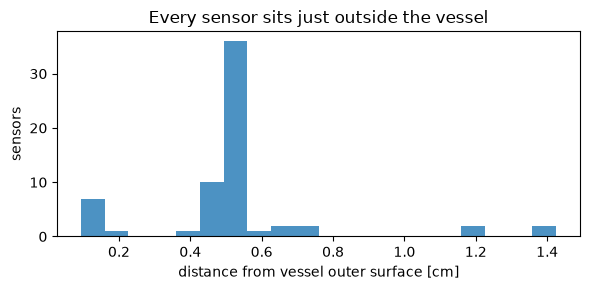

In [4]:
inner = np.array(geom["vv"]["inner_contour"])
outer = np.array(geom["vv"]["outer_contour"])

def distance_to_curve(p, curve):
    """Shortest distance from point p to a closed polyline."""
    a, b = curve, np.roll(curve, -1, axis=0)
    keep = np.any(a != b, axis=1)   # the contour repeats its first point; skip that empty segment
    a, b = a[keep], b[keep]
    ab = b - a
    t = np.clip(np.einsum("ij,ij->i", p - a, ab) / np.einsum("ij,ij->i", ab, ab), 0, 1)
    return np.min(np.linalg.norm(p - (a + t[:, None] * ab), axis=1))

chamber = Path(inner)       # the space the plasma lives in
whole_vessel = Path(outer)  # chamber plus the 5 mm steel wall
rows = []
for s in sensors.flux_loops + sensors.mirnov_probes:
    p = np.array([s["R"], s["Z"]])
    in_chamber = chamber.contains_point(p)
    in_wall = whole_vessel.contains_point(p) and not in_chamber
    rows.append((s["id"], distance_to_curve(p, outer) * 100, in_chamber, in_wall))

gaps = np.array([r[1] for r in rows])
print(f"distance from the vessel's outer surface: median {np.median(gaps):.2f} cm, "
      f"max {gaps.max():.2f} cm")
print("sensors inside the vacuum chamber:", [r[0] for r in rows if r[2]] or "none")
print("sensors inside the steel wall itself:", [r[0] for r in rows if r[3]] or "none")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(gaps, bins=20, color="tab:blue", alpha=0.8)
ax.set_xlabel("distance from vessel outer surface [cm]")
ax.set_ylabel("sensors")
ax.set_title("Every sensor sits just outside the vessel")
plt.tight_layout()
plt.show()

Almost every sensor sits about half a centimetre outside the vessel, which
is what sensors mounted on it should do. That agreement between two independent
sources is good evidence the table was transcribed correctly.

Two sensors are worth a closer look. `FS22` and `FS25` (R = 0.162 m) come out
2 to 3 mm from the outer surface on the *inside*, that is, within the 5 mm
steel wall itself, while their neighbours sit at R = 0.165 m. That is most
likely a groove in the wall or rounding in the table. It is not a transcription
error, but it is the kind of detail to confirm with whoever made the table,
rather than to silently "fix".

The same check runs automatically in `tests/test_forward.py`, so a future edit
that breaks the table fails the test suite.

## 3. How much does each parameter change the readings?

Now the main question. A sensor set can only determine a parameter if changing
that parameter changes the readings by more than the noise. So measure it.

The noise model is the one used for training: each channel gets Gaussian noise
with a standard deviation of 2% of that channel's typical signal. Call that
$\sigma_i$ for channel $i$. A change $\Delta s_i$ is then measured in **noise
units**, $\Delta s_i / \sigma_i$, and the size of a whole change across all 64
channels is

$$\text{size} = \sqrt{\sum_i (\Delta s_i / \sigma_i)^2}.$$

A size of about 1 is one noise-width: roughly the smallest change that can be
told apart from noise at all. A size of 10 is easy to see.

In [5]:
X_ref, _, _ = generate_dataset(n_samples=4000, noise_frac=0.0, seed=0, layout=layout)
sigma = 0.02 * np.abs(X_ref).mean(axis=0)     # the training noise level, per channel

base = np.array([1.5e5, 0.32, 0.0, 0.12])     # Ip [A], R0 [m], Z0 [m], a [m]
s_base = forward_signals(*base, layout)

changes = {
    "Ip up 5%": base * [1.05, 1, 1, 1],
    "R0 out 1 cm": base + [0, 0.01, 0, 0],
    "Z0 up 1 cm": base + [0, 0, 0.01, 0],
    "a from 12 to 16 cm": base + [0, 0, 0, 0.04],
}
size = {}
for label, p in changes.items():
    d = forward_signals(*p, layout) - s_base
    size[label] = np.linalg.norm(d / sigma)
    print(f"{label:<20} size {size[label]:6.1f} noise units")

Ip up 5%             size   22.0 noise units
R0 out 1 cm          size   33.5 noise units
Z0 up 1 cm           size   27.1 noise units
a from 12 to 16 cm   size    8.9 noise units


Every one of these is far above one noise-width, including the change in `a`.
So `a` is **not** invisible: widening the current channel by 4 cm changes the
readings clearly. That rules out the simplest explanation ("the signal is too
small") and points to a subtler one.

## 4. The look-alike problem

A parameter can change the readings a lot and still be impossible to measure,
if **some other combination of parameters changes them in the same pattern**.
Then the readings cannot say which one happened.

To test this, take the change caused by one parameter and ask: what is the
best imitation of it using only the *other* three? Fit that imitation by least
squares (weighted by the noise), and measure what is left over. The leftover
is the part of the fingerprint that only this parameter can produce, and it is
what an estimator actually has to work with.

In [6]:
def jacobian(p, lay):
    """How each reading changes per unit change of each parameter (central differences)."""
    steps = np.array([100.0, 1e-4, 1e-4, 1e-4])
    J = np.zeros((lay.n_sensors, 4))
    for j in range(4):
        e = np.zeros(4)
        e[j] = steps[j]
        J[:, j] = (forward_signals(*(p + e), lay) - forward_signals(*(p - e), lay)) / (2 * steps[j])
    return J

J = jacobian(base, layout) / sigma[:, None]    # in noise units per unit parameter

print(f"{'change':<20}{'size':>8}{'left after best imitation':>28}{'share unique':>15}")
for (label, p), j in zip(changes.items(), range(4)):
    d = (forward_signals(*p, layout) - s_base) / sigma
    others = [k for k in range(4) if k != j]
    coef, *_ = np.linalg.lstsq(J[:, others], d, rcond=None)
    left = np.linalg.norm(d - J[:, others] @ coef)
    print(f"{label:<20}{size[label]:>8.1f}{left:>28.2f}{left / size[label]:>14.0%}")
    if label.startswith("a "):
        imitation = dict(zip([PARAM_NAMES[k] for k in others], coef))

print(f"\nbest imitation of 'a from 12 to 16 cm': R0 {imitation['R0'] * 1e3:+.1f} mm, "
      f"Ip {imitation['Ip']:+.0f} A, Z0 {imitation['Z0'] * 1e3:+.3f} mm")

change                  size   left after best imitation   share unique
Ip up 5%                22.0                       18.13           82%
R0 out 1 cm             33.5                        1.66            5%
Z0 up 1 cm              27.1                       27.07          100%
a from 12 to 16 cm       8.9                        0.67            8%

best imitation of 'a from 12 to 16 cm': R0 +2.8 mm, Ip -40 A, Z0 -0.004 mm


This is the answer, and it has a twist.

- **`Ip` and `Z0`** have fingerprints that are mostly or entirely their own: no
  combination of the other parameters can fake them, so the readings pin them
  down.
- **`a`** is almost entirely imitable: widening the current by 4 cm looks like
  moving the plasma **outward by about 3 mm**. What only `a` can explain is
  below one noise-width.
- **`R0`** is also mostly imitable, and the imitator is `a`. The look-alike
  runs both ways: `a` and `R0` form one ambiguous pair.

So why is `R0` recovered well and `a` not? Because of the exchange rate. Four
centimetres of `a` buys only about 3 mm of `R0`. To fake a 1 cm shift in `R0`,
`a` would have to change by more than 10 cm, which is most of its whole allowed
range (5 to 18 cm). So `R0` can only be wrong by a few millimetres before the
imitation runs out of room, while `a` can be wrong by centimetres at a cost of
only a few millimetres of `R0`. With 2% noise, "the current is wider" and "the
current is a little further out" are practically indistinguishable, and the
parameter that absorbs the confusion is `a`.

**Why widening looks like moving outward.** For a straight wire, the field
outside a round bundle of current depends only on the total current and the
centre of the bundle, not its width (the same way gravity outside a planet
depends only on its mass and centre). A tokamak's current runs in a ring, and
in a ring the current on the outer side (larger `R`) contributes more flux than
the current on the inner side. So spreading the current out shifts its
"effective centre" slightly outward, and from outside that is what the sensors
see. The next cell shows it directly.

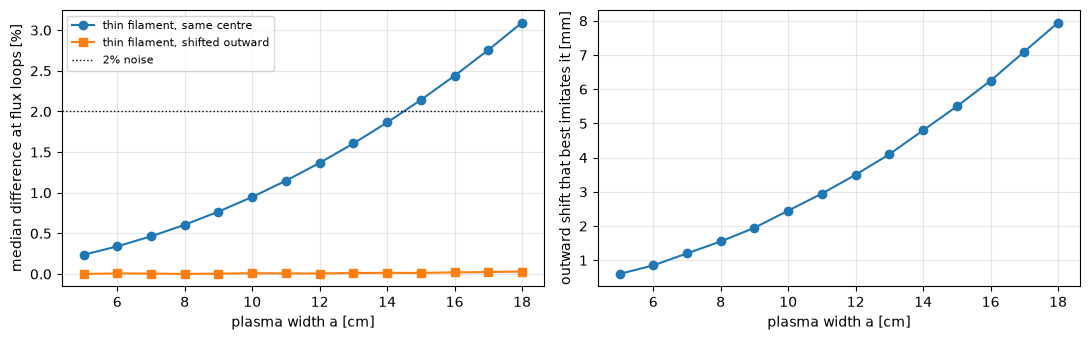

a = 18 cm: 3.1% different from a thin filament at the same centre, 0.03% from one shifted out by 8.0 mm


In [7]:
fl_R, fl_Z = layout.fl_R, layout.fl_Z
plasma_widths = np.linspace(0.05, 0.18, 14)
thin_same_centre, thin_best_shift = [], []
for a in plasma_widths:
    s_plasma = forward_signals(1.5e5, 0.32, 0.0, a, layout)[: len(fl_R)]
    # a single thin filament with the same current at the same centre
    s_thin = loop_flux(0.32, 0.0, 1.5e5, fl_R, fl_Z)
    thin_same_centre.append(np.median(np.abs(s_plasma - s_thin) / np.abs(s_thin)))
    # the same thin filament, moved outward by whatever amount matches best
    shifts = np.linspace(0, 0.02, 401)
    errs = [np.median(np.abs(s_plasma - loop_flux(0.32 + d, 0.0, 1.5e5, fl_R, fl_Z)) / np.abs(s_plasma))
            for d in shifts]
    thin_best_shift.append((shifts[int(np.argmin(errs))], min(errs)))

thin_best_shift = np.array(thin_best_shift)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(plasma_widths * 100, np.array(thin_same_centre) * 100, "o-", label="thin filament, same centre")
axes[0].plot(plasma_widths * 100, thin_best_shift[:, 1] * 100, "s-", label="thin filament, shifted outward")
axes[0].axhline(2, color="k", ls=":", lw=1, label="2% noise")
axes[0].set_xlabel("plasma width a [cm]")
axes[0].set_ylabel("median difference at flux loops [%]")
axes[0].legend(fontsize=8)
axes[1].plot(plasma_widths * 100, thin_best_shift[:, 0] * 1000, "o-")
axes[1].set_xlabel("plasma width a [cm]")
axes[1].set_ylabel("outward shift that best imitates it [mm]")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"a = 18 cm: {thin_same_centre[-1]:.1%} different from a thin filament at the same centre, "
      f"{thin_best_shift[-1, 1]:.2%} from one shifted out by {thin_best_shift[-1, 0] * 1e3:.1f} mm")

Left: a wide plasma differs noticeably from a thin filament at the same
centre, but a thin filament nudged outward matches it far more closely, to
within a fraction of the noise. Right: the wider the plasma, the larger the
nudge needed, roughly in proportion to the width squared (doubling the width
from 5 to 10 cm quadruples the shift). That is the look-alike from section 4,
seen at the flux loops.

## 5. The best any method could do

There is a standard tool that turns this into a number: the **Cramér-Rao
bound**. Given the noise and how the readings depend on each parameter
(the matrix `J` above), it gives the smallest error an unbiased estimator could
possibly achieve, whether that estimator is least squares, a neural network, or
anything else. It is computed from the **Fisher information** $F = J^T J$
(with `J` in noise units): the bound on each parameter's error is the square
root of the matching diagonal entry of $F^{-1}$.

Two versions are informative:

- the **real** bound, where every parameter is unknown at once; and
- the bound **if the other three were known exactly**. The gap between the two
  is the look-alike problem in numbers.

The bounds are compared with each parameter's **range spread** (the standard
deviation of the range it is sampled from). A bound much smaller than that means
"well determined"; a bound larger than it means "the data says less than the
training range already did".

In [8]:
def bounds(J):
    F = J.T @ J
    return np.sqrt(np.diag(np.linalg.inv(F))), 1 / np.sqrt(np.diag(F))

crb, crb_if_others_known = bounds(J)
spread = np.array([(PARAM_RANGES[n][1] - PARAM_RANGES[n][0]) / np.sqrt(12) for n in PARAM_NAMES])
units = [("kA", 1e-3), ("mm", 1e3), ("mm", 1e3), ("mm", 1e3)]

print(f"{'':<5}{'best possible error':>21}{'if others known':>18}{'range spread':>15}")
for n, c, k, sp, (u, f) in zip(PARAM_NAMES, crb, crb_if_others_known, spread, units):
    print(f"{n:<5}{c * f:>17.2f} {u}{k * f:>14.2f} {u}{sp * f:>11.1f} {u}")

cov = np.linalg.inv(J.T @ J)
corr = cov[1, 3] / np.sqrt(cov[1, 1] * cov[3, 3])
print(f"\ncorrelation between the errors in R0 and a: {corr:+.3f}")

       best possible error   if others known   range spread
Ip                0.41 kA          0.34 kA       66.4 kA
R0                7.70 mm          0.31 mm       23.1 mm
Z0                0.37 mm          0.37 mm       34.6 mm
a               133.83 mm          5.39 mm       37.5 mm

correlation between the errors in R0 and a: -0.999


Read the `a` row. With every parameter unknown, the best possible error on
`a` is several times larger than its whole range spread. If `R0` were known,
it would be a few millimetres. The correlation of almost exactly -1 says the
same thing: any error in `a` can be cancelled by an opposite error in `R0`.

This also explains a detail from notebook 03 that might have looked odd. The
bound on `R0` here is several millimetres, yet the surrogate gets `R0` to about
2 mm. The difference is the exchange rate from section 4: the surrogate knows
`a` must lie between 5 and 18 cm (that is all it ever saw in training), which
caps how much of `a`'s ambiguity can leak into `R0`. The Cramér-Rao bound
assumes no such prior knowledge. A bounded training range is information too.

**The limits of this calculation.** It is local (computed at one plasma state),
it assumes the noise model is right, and it describes this reduced model's
physics, not a real Grad-Shafranov equilibrium.

## 6. What a sensor inside the plasma would change

An earlier version of this project used an **invented** sensor layout, and with
it the surrogate scored R2 of about 0.95 on `a`. One of its flux loops sat 1.3 cm
from the plasma centre, inside the plasma. No real tokamak can put a sensor
there (it would be destroyed and would contaminate the plasma), but the model
did not know that. Here is what such a sensor does to the problem.

interior loop reading changes by 41% as a goes from 5 to 18 cm

         real sensors    plus one interior loop
Ip           0.41 kA                  0.41 kA
R0           7.70 mm                  0.45 mm
Z0           0.37 mm                  0.37 mm
a          133.83 mm                  4.90 mm


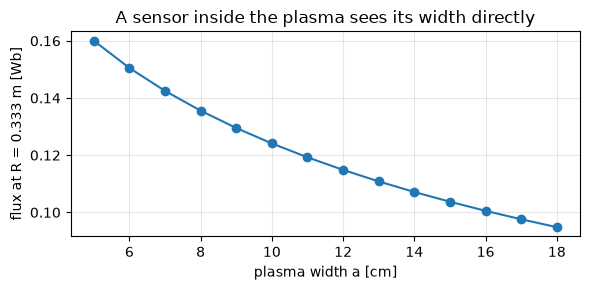

In [9]:
inside = SensorLayout(fl_R=np.array([0.333]), fl_Z=np.array([0.0]),
                      mp_R=np.array([]), mp_Z=np.array([]), mp_cos=np.array([]), mp_sin=np.array([]))
r_in = [forward_signals(1.5e5, 0.32, 0.0, a, inside)[0] for a in plasma_widths]
print(f"interior loop reading changes by {abs(r_in[-1] - r_in[0]) / abs(r_in[0]):.0%} "
      f"as a goes from 5 to 18 cm")

# add that one loop to CUTE's real set and recompute the bounds
with_inside = SensorLayout(np.r_[layout.fl_R, 0.333], np.r_[layout.fl_Z, 0.0],
                           layout.mp_R, layout.mp_Z, layout.mp_cos, layout.mp_sin)
n_fl = len(layout.fl_R)
sigma_inside = np.r_[sigma[:n_fl], 0.02 * abs(forward_signals(*base, inside)[0]), sigma[n_fl:]]
crb_inside, _ = bounds(jacobian(base, with_inside) / sigma_inside[:, None])

print(f"\n{'':<5}{'real sensors':>16}{'plus one interior loop':>26}")
for n, c0, c1, (u, f) in zip(PARAM_NAMES, crb, crb_inside, units):
    print(f"{n:<5}{c0 * f:>12.2f} {u}{c1 * f:>22.2f} {u}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(plasma_widths * 100, r_in, "o-")
ax.set_xlabel("plasma width a [cm]")
ax.set_ylabel("flux at R = 0.333 m [Wb]")
ax.set_title("A sensor inside the plasma sees its width directly")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

From inside, the width is no longer hidden. The reading changes by tens of
percent across the range, and adding that single loop shrinks the best possible
error on `a` from far larger than its range to a few millimetres. That is why
the invented layout made `a` look easy, and why the honest numbers dropped when
CUTE's real positions went in. The network did not get worse. The earlier score
belonged to a sensor that cannot exist.

## 7. How real reconstruction deals with this

The same kind of problem appears in real tokamaks, and it is one of the classic
results in the field. For a plasma with a nearly circular cross-section,
magnetic measurements from outside determine the plasma current, its position,
and one particular combination of pressure and current profile,
$\beta_p + l_i/2$ (the poloidal beta plus half the internal inductance), but
not the two separately. Pressure and a peaked current both push the plasma
outward in similar ways, so from outside you see their sum. That is the real
version of what sections 4 and 5 found: a "how is it distributed inside" quantity
that hides behind a "how far out does it sit" quantity.

Real reconstruction codes such as EFIT get further in three ways:

- **The boundary comes from the equilibrium, not from a width parameter.** The
  plasma edge is the last closed flux surface, set by where the flux surfaces
  touch the wall (the limiter) or pass through an X-point. A Grad-Shafranov
  solve fixes that, so boundary size and shape are much better determined than
  the internal current distribution. The reduced model here has no such edge:
  its `a` is purely the width of the current.
- **Shaping helps.** Elongated, D-shaped plasmas (CUTE targets elongation about
  1.7) break some of the symmetry that makes a circular plasma so degenerate.
- **Other diagnostics** (internal field measurements, pressure profiles) add
  information from inside that magnetics alone cannot.

The route forward for this project is the Grad-Shafranov training set,
`scripts/generate_gs_dataset.py`. It solves real free-boundary equilibria with
TokaMaker, so its labels include a genuine boundary and genuine $l_i$ and
$\beta_p$. It needs the Open Fusion Toolkit, and must be regenerated for CUTE's
real sensor layout.

## Questions a physicist would ask

**"So the surrogate cannot measure the plasma's size?"** In this reduced model,
`a` means the width of the current channel, not the plasma edge. Its signal is
almost identical to a small outward shift, so from CUTE's external sensors it is
barely determined, by any method. In a real equilibrium the edge is set
differently and is much better constrained; what stays hard is how current is
distributed inside it.

**"How do you know it is the sensors and not your network?"** The Cramér-Rao
bound in section 5 uses no network at all. It says no unbiased method could do
much better than guessing within the training range, and the classical
inversion in notebook 02 fails the same way.

**"Why did your R2 for `a` drop from 0.95?"** The earlier layout was invented
and included a flux loop inside the plasma. Section 6 shows that one such loop
is enough to make `a` easy. CUTE's real sensors are all outside the vessel.

**"Would more external sensors fix it?"** Only partly. More sensors in similar
places mostly reduce noise, and the look-alike would still be there. What helps
is information of a different kind: a Grad-Shafranov equilibrium with a real
boundary, a shaped plasma, or diagnostics that see inside.